In [95]:
import torch
import torch as t
import torch as tc
import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.models as models
from torchvision.utils import save_image
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import Markdown as md

#                                           Класифікація зображеньі базова згорткова мережа
Бізнес-контекст
- Компанія VisionScan AI розробляє систему автоматичного розпізнавання рукописних цифр для обробки банківських документів.
- Ваше завдання — створити першу версію моделі, яка класифікує цифри 0-9 за зображеннями, використовуючи PyTorch.

### Завдання 1
Підготуйте дані.
- Використовуйте датасет MNIST із torchvision.datasets.
- Завантажте навчальну і тестову вибірки.
- Перетворіть зображення в тензори та нормалізуйте їх.
- Створіть DataLoader із батчем розміром 64.

In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5))
])

train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)

In [23]:
batch_size = 64
train_loader = DataLoader(dataset = train_dataset, batch_size=batch_size, shuffle=True)
tast_loader  = DataLoader(dataset = test_dataset, batch_size= batch_size,  shuffle=False)

64


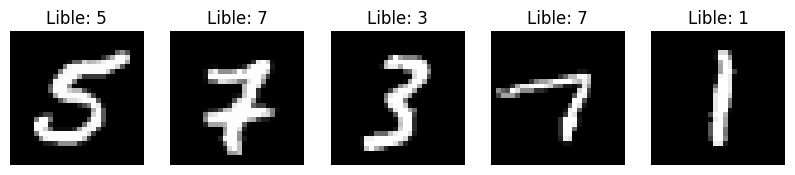

tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1

In [81]:
import matplotlib.pyplot as plt
train_iter = iter(train_loader)
images, labels = next(train_iter)
print(len(labels))

plt.figure(figsize=(10, 2))
for i in range(5) :
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Lible: {labels[i]}")
    plt.axis("off")
plt.show()

images[0]

### Завдання 2
Побудуйте просту згорткову нейронну мережу.
- Використовуйте шари:
    - Conv2d(1, 16, kernel_size=3);
    - ReLU();
    - MaxPool2d(2);
    - Flatten();
    - Linear(16 * 13 * 13, 10).
- Функція втрат — CrossEntropyLoss, оптимізатор — Adam(lr=0.001).
- Навчіть модель 10 епох.

In [54]:
class ConvNN(nn.Module):
    def __init__(self):
        super(ConvNN, self).__init__()
        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
        )
        self.rule = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16 * 13 * 13, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.rule(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x
        
model = ConvNN()
loss_f = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [56]:
epochs = 10
losses = []
for epoch in range(epochs) :
    total_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = loss_f(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)
    print(f"Epoch: {epoch+1}, Loss: {total_loss}")

Epoch: 1, Loss: [24.436739924422]
Epoch: 2, Loss: [24.436739924422, 21.95273548841942]
Epoch: 3, Loss: [24.436739924422, 21.95273548841942, 19.54369628187851]
Epoch: 4, Loss: [24.436739924422, 21.95273548841942, 19.54369628187851, 17.766229411266977]
Epoch: 5, Loss: [24.436739924422, 21.95273548841942, 19.54369628187851, 17.766229411266977, 16.061855228530476]
Epoch: 6, Loss: [24.436739924422, 21.95273548841942, 19.54369628187851, 17.766229411266977, 16.061855228530476, 15.313869745936245]
Epoch: 7, Loss: [24.436739924422, 21.95273548841942, 19.54369628187851, 17.766229411266977, 16.061855228530476, 15.313869745936245, 12.618767023930559]
Epoch: 8, Loss: [24.436739924422, 21.95273548841942, 19.54369628187851, 17.766229411266977, 16.061855228530476, 15.313869745936245, 12.618767023930559, 12.144376473806915]
Epoch: 9, Loss: [24.436739924422, 21.95273548841942, 19.54369628187851, 17.766229411266977, 16.061855228530476, 15.313869745936245, 12.618767023930559, 12.144376473806915, 10.638728

### Завдання 3
Відстежуйте та візуалізуйте процес навчання.
- Виведіть втрати за епохами.
- Побудуйте графік залежності loss від епох.
- Збережіть модель у файл mnist_cnn.pth.

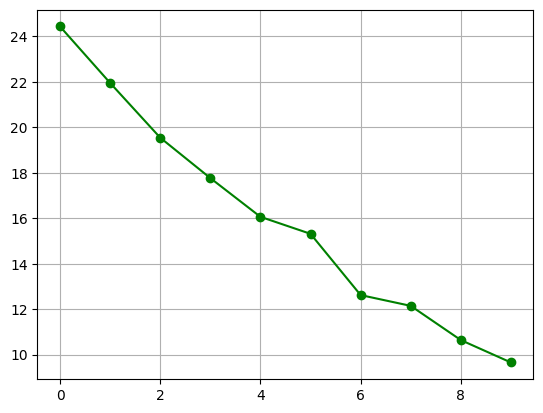

In [73]:

plt.plot(losses, 'g-o')
plt.grid()
plt.show()

In [80]:
correct = 0
total= 0 
mis = []
with torch.no_grad():
    for images, labels in tast_loader :
        output = model(images)
        _, predicted = torch.max(output, 1)
        total += len(labels)
        correct += (predicted == labels).sum().item()

        for i in range(len(labels)) : 
            if predicted[i] != labels[i] :
                mis.append({
                    "label": labels[i],
                    "prediction":predicted[i],
                    "image": images[i]
                })
print(len(mis))

192


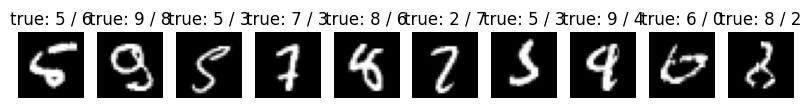

In [96]:
plt.figure(figsize=(10, 2))
for i in range(10) :
    plt.subplot(1, 10, i+1)
    plt.imshow(mis[i]['image'].squeeze(), cmap="gray")
    plt.title(f"true: {mis[i]['label']} / {mis[i]['prediction']}")
    plt.axis("off")
plt.show()

In [113]:
a = (correct / total) * 100
md (f"""
|Метрика|Значення|
|-|-|
|Accuracy|{a}%|
|Loss|{(100 - a):1f}%|
""")


|Метрика|Значення|
|-|-|
|Accuracy|98.08%|
|Loss|1.920000%|
